# ROC and PR Curves and AUC Metric

To-do:
- Better intro text
- Put utils on separate .py
- Elaborate on why ROC and PR are insensitive/sensitive on inbalanced dataset

In [1]:

import random
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Any
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

# Models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Dataviz
from matplotlib.colors import rgb2hex
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib
import seaborn as sns
import plotly.express as px


In [2]:
from roc_auc import plotly_roc_auc, plotly_pr_auc

# Dataset Creation and Modeling

In [3]:

# --- Dataset Creation ---
X, y = make_classification(n_samples=1000, n_features=10, n_informative=4, flip_y=0.2, weights=[0.8, 0.2],random_state=42)
y = y.reshape(-1, 1)
df = pd.DataFrame(np.concatenate([X, y], axis=1))

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
df_train, df_test = train_test_split(df, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

x_columns = df.columns[:10]
y_column = df.columns[10]

X_train_df = df_train[x_columns]
X_test_df = df_test[x_columns]
y_train_df = df_train[y_column]
y_test_df = df_test[y_column]

model = LogisticRegression()
model.fit(X_train_df, y_train_df)

LogisticRegression()

# ROC Curve

The **Receiver Operating Characteristic (ROC)** Curve visualizes the trade-off between the **True Positive Rate** and the **False Positive Rate** across **different classification thresholds**.

It helps assess a model's ability to distinguish between classes, regardless of the decision threshold. The Area Under the ROC Curve (AUC) quantifies this performance — with 1.0 indicating perfect separation and 0.5 representing random guessing.

In [4]:
dataset_dict = {
    "Train":
    {
        "x": X_train_df,
        "y": y_train_df,
        "y_pred": model.predict(X_train_df),
        "y_prob": model.predict_proba(X_train_df),
    },
    "Test":
    {
        "x": X_test_df,
        "y": y_test_df,
        "y_pred": model.predict(X_test_df),
        "y_prob": model.predict_proba(X_test_df),
    },
}

plotly_roc_auc(dataset_dict)


# PR Curve

The **Precision-Recall (PR)** Curve shows the relationship between **Precision** (positive predictive value) and **Recall** (true positive rate) for **various thresholds**.

It is especially useful in imbalanced classification problems, where the positive class is rare. A higher curve indicates better performance in retrieving relevant positives while minimizing false positives, with Average Precision (AP) summarizing the overall area under the curve.

<br><br>
**What about the horizontal line?**

It represents the **"no-skill classifier baseline"** in a PR curve, meant to be a reference point.

The no-skill classifier is a theoretical model that guesses randomly **but preserves the class distribution** or that always predicts the positive class at a fixed rate.

It is a horizontal line because its precision will be equal to the prevalence (base rate) of the positive class, no matter the recall.

If your PR curve is below the line, this means that it is worse than random guessing.


In [5]:
plotly_pr_auc(dataset_dict)


# Differences between ROC and PR Curves


**ROC and PR curves measure different things**:

| Curve Type                      |                   ROC            | PR                                |
| ------------------------------  | ------------------------------   | --------------------------------- |
| Sensitivity to Class Imbalance  | Insensitive                      | Sensitive                         |
| Works well on balanced dataset  | ✅                              | ✅                                |
| Works well on inbalanced dataset| ⚠️ Can be misleading            | ✅                                |
| Baseline Meaning                | Diagonal line (TPR = FPR)        | Horizontal at positive class rate |
| X-axis                          | False Positive Rate              | Recall                            |
| Y-axis                          | True Positive Rate               | Precision                         |
| Measures ranking ability        | ✅                              | ❌                               |
| Focus on rare positive detection| ❌                              | ✅                               |
| Threshold selection matters     | ❌                              | ✅                               |
| Symmetric class importance      | ✅                              | ❌                               |
| Precision is critical           | ❌                              | ✅                               |

So even **the same model** can look very different in ROC vs PR curves, especially on **imbalanced datasets**.


In [6]:
X_bal, y_bal = make_classification(n_samples=1000, n_classes=2, weights=[0.5, 0.5], flip_y=0.01, random_state=42)
X_imbal, y_imbal = make_classification(n_samples=1000, n_classes=2, weights=[0.95, 0.05], flip_y=0.01, random_state=42)

# Train logistic regression models on both datasets
model_bal = LogisticRegression().fit(X_bal, y_bal)
model_imbal = LogisticRegression().fit(X_imbal, y_imbal)


y_pred_bal = model_bal.predict(X_bal)
y_pred_imbal = model_bal.predict(X_imbal)

tp_bal = int(((y_pred_bal == 1) & (y_bal == 1)).sum())
fp_bal = int(((y_pred_bal == 1) & (y_bal == 0)).sum())
tn_bal = int(((y_pred_bal == 0) & (y_bal == 0)).sum())
fn_bal = int(((y_pred_bal == 0) & (y_bal == 1)).sum())


tp_imbal = int(((y_pred_imbal == 1) & (y_imbal == 1)).sum())
fp_imbal = int(((y_pred_imbal == 1) & (y_imbal == 0)).sum())
tn_imbal = int(((y_pred_imbal == 0) & (y_imbal == 0)).sum())
fn_imbal = int(((y_pred_imbal == 0) & (y_imbal == 1)).sum())


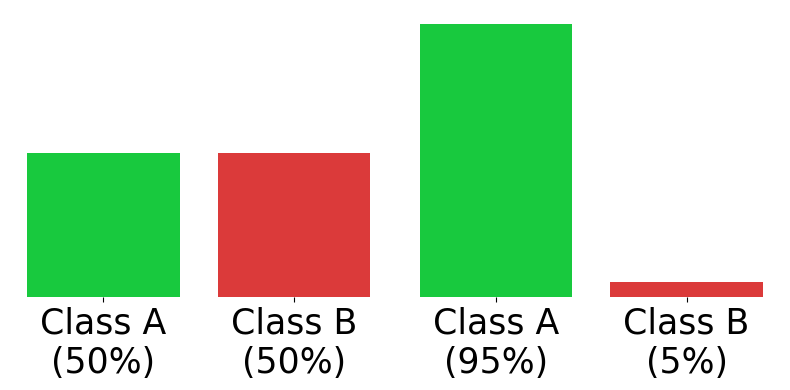

In [7]:
# sns.barplot(y_imbal)

import matplotlib.pyplot as plt

n_samples = 1000
X_bal, y_bal = make_classification(n_samples=n_samples, n_classes=2, weights=[0.5, 0.5], flip_y=0.01, random_state=42)
X_imbal, y_imbal = make_classification(n_samples=n_samples, n_classes=2, weights=[0.95, 0.05], flip_y=0.01, random_state=42)


# Data
sizes = [[(y_bal==0).sum(), (y_bal==1).sum()], [(y_imbal==0).sum(), (y_imbal==1).sum()]]
labels = [
    [f'Class A\n({sizes[0][0]/n_samples*100:.0f}%)', f'Class B\n({sizes[0][1]/n_samples*100:.0f}%)'],
    [f'Class A\n({sizes[1][0]/n_samples*100:.0f}%)', f'Class B\n({sizes[1][1]/n_samples*100:.0f}%)']
]
colors = ["#18c93e", "#db3a3a"]

# Plot
fig, axes = plt.subplots(ncols=2, figsize=(8,4), sharey=True)

for ax, size, label in zip(axes, sizes, labels):

    ax.bar(x=label, height=size, color=colors)
    # plt.title('Class Imbalance Example', fontsize=14)
    ax.tick_params(axis='x', labelsize=25)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    plt.yticks([])
plt.tight_layout()
plt.show()


In [8]:
# ROC
# X-axis = False Positive Rates
# Y-axis = True Positive Rate = Recall

fpr_bal = fp_bal / (fp_bal + tn_bal)
tpr_bal = tp_bal / (tp_bal + fn_bal)

fpr_imbal = fp_imbal / (fp_imbal + tn_imbal)
tpr_imbal = tp_imbal / (tp_imbal + fn_imbal)

# PR
# X-axis = True Positive Rate = Recall
# Y-axis = Precision

prec_bal = tp_bal / (tp_bal + fp_bal)
prec_imbal = tp_imbal / (tp_imbal + fp_imbal)

print(fpr_bal, tpr_bal)
print(fpr_imbal, tpr_imbal)
print()
print(tpr_bal, prec_bal)
print(tpr_imbal, prec_imbal)


0.11 0.864
0.11298838437170011 0.8113207547169812

0.864 0.8870636550308009
0.8113207547169812 0.2866666666666667


# ROC and PR Curves on Imbalanced Datasets

Why is ROC insensitive on class imbalance, while PR is sensitive?

Because the X-axis measures False Positive Rates, and the Y-axis measures True Positive Rate,

Even if your dataset has 99% negatives and 1% positives, a model’s ROC curve and AUC score won’t change much, as long as the model ranks positives above negatives similarly.




But the PR X-axis measures Recall, and the Y-axis measures Precision, but **Precision depends on class balance**.




---

## 📊 ROC Curve: Diagonal = Random Guessing

In the **ROC space**:

* X-axis: **False Positive Rate**
* Y-axis: **True Positive Rate**

A **random model** (e.g., flipping a coin) gives:

$$
\text{TPR} = \text{FPR}
$$

This creates the **diagonal line** — any point on it is the result of a random threshold.

🔹 **Balanced or imbalanced data doesn’t affect this diagonal**, because ROC measures **rates**, not absolute counts.

---

## 📈 PR Curve: Horizontal Line = Baseline Precision

In the **PR space**:

* X-axis: **Recall**
* Y-axis: **Precision**

Here’s the key: **Precision depends on class balance**.

For a **random guesser**, the chance that a predicted positive is actually correct is:

$$
\text{Precision} = \frac{\text{Positives}}{\text{Total Samples}} = \text{Positive Class Rate}
$$

So if your dataset is:

* 50% positive → baseline precision is 0.5
* 10% positive → baseline precision is 0.1

🔹 Hence, the **horizontal line at the positive class rate**.

---


## ✅ TL;DR

> **Random guessing = diagonal in ROC space = horizontal at positive rate in PR space.**
> These look different because ROC cares about **ranking** and is class-balance agnostic, while PR cares about **positive prediction quality**, which is **very sensitive to class imbalance**.

---

Let me know if you want a dual plot to visually compare these — happy to mock it up.


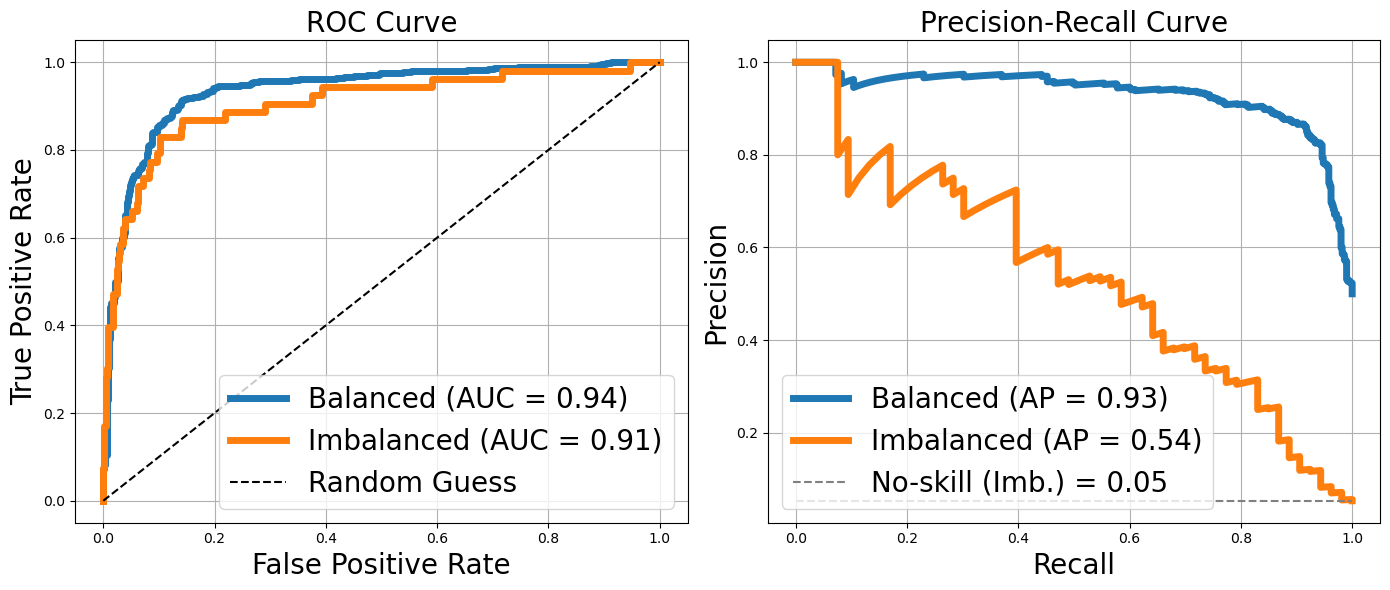

In [9]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.datasets import make_classification
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (
#     roc_curve, precision_recall_curve,
#     roc_auc_score, average_precision_score
# )

# Generate two datasets: one balanced, one imbalanced
X_bal, y_bal = make_classification(n_samples=1000, n_classes=2, weights=[0.5, 0.5], flip_y=0.01, random_state=42)
X_imbal, y_imbal = make_classification(n_samples=1000, n_classes=2, weights=[0.95, 0.05], flip_y=0.01, random_state=42)

# Train logistic regression models on both datasets
model_bal = LogisticRegression().fit(X_bal, y_bal)
model_imbal = LogisticRegression().fit(X_imbal, y_imbal)

# Get predicted probabilities
y_prob_bal = model_bal.predict_proba(X_bal)[:, 1]
y_prob_imbal = model_imbal.predict_proba(X_imbal)[:, 1]

# Compute ROC and PR metrics
fpr_bal, tpr_bal, _ = roc_curve(y_bal, y_prob_bal)
prec_bal, rec_bal, _ = precision_recall_curve(y_bal, y_prob_bal)
roc_auc_bal = roc_auc_score(y_bal, y_prob_bal)
ap_bal = average_precision_score(y_bal, y_prob_bal)

fpr_imbal, tpr_imbal, _ = roc_curve(y_imbal, y_prob_imbal)
prec_imbal, rec_imbal, _ = precision_recall_curve(y_imbal, y_prob_imbal)
roc_auc_imbal = roc_auc_score(y_imbal, y_prob_imbal)
ap_imbal = average_precision_score(y_imbal, y_prob_imbal)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
axes[0].plot(fpr_bal, tpr_bal, linewidth=5, label=f"Balanced (AUC = {roc_auc_bal:.2f})")
axes[0].plot(fpr_imbal, tpr_imbal, linewidth=5, label=f"Imbalanced (AUC = {roc_auc_imbal:.2f})")
axes[0].plot([0, 1], [0, 1], 'k--', label="Random Guess")
axes[0].set_title("ROC Curve", fontsize=20)
axes[0].set_xlabel("False Positive Rate", fontsize=20)
axes[0].set_ylabel("True Positive Rate", fontsize=20)
axes[0].legend(fontsize=20)
axes[0].grid(True)

# PR curves
axes[1].plot(rec_bal, prec_bal, linewidth=5, label=f"Balanced (AP = {ap_bal:.2f})")
axes[1].plot(rec_imbal, prec_imbal, linewidth=5, label=f"Imbalanced (AP = {ap_imbal:.2f})")
baseline_imbal = y_imbal.mean()
axes[1].hlines(baseline_imbal, 0, 1, colors='gray', linestyles='dashed',
               label=f"No-skill (Imb.) = {baseline_imbal:.2f}")
axes[1].set_title("Precision-Recall Curve", fontsize=20)
axes[1].set_xlabel("Recall", fontsize=20)
axes[1].set_ylabel("Precision", fontsize=20)
axes[1].legend(fontsize=20)
axes[1].grid(True)

plt.tight_layout()
plt.show()


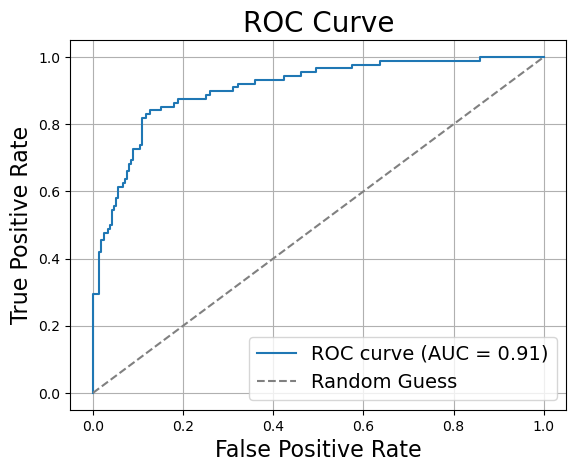

In [10]:

# Sample binary classification data
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.7, 0.3], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC data
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("ROC Curve", fontsize=20)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()